# SCN Formulation Comparison

We examine four interpretations of Self-Containment Nullification, each with hard and soft variants, and compare their predictions against standard QFT and experiment.

| Key | Formulation | Rule | 1-loop Self-Energy |
|-----|------------|------|-------------------|
| **LIT** | Literal | S ∈ S strictly — only resummed/Dyson structures | **Survives** |
| **STR** | Structural | Sub-structure isomorphic to what is being corrected | **Nullified** |
| **DIA** | Diagrammatic | Self-energy of X contains internal X propagator | **Nullified** |
| **PHY** | Physical | Self-referential at dressed-propagator / Dyson level | **Survives** |

Key question: which formulation(s) are **viable** — i.e., consistent with experiment at the precision level where they make predictions?

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from src.scn_models import (
    make_all_models, make_model,
    LiteralSCN, StructuralSCN, DiagrammaticSCN, PhysicalSCN,
    SCNVerdict,
)
from src.observables import (
    diagram_classification_table, alpha_s_running, alpha_running,
    sigma_ee_mumu, g_minus_2, lamb_shift,
    beta_function_table, r_ratio, full_comparison,
    ALPHA, ALPHA_S_MZ, M_Z,
)
from src.diagrams import get_all_one_loop_qed, get_all_one_loop_qcd

# Build all 8 models: 4 formulations × {hard, soft}
hard_models = make_all_models(soft=False)
soft_models = make_all_models(soft=True, lambda_scn=0.1)
all_models  = hard_models + soft_models

print(f"Loaded {len(all_models)} SCN models:")
for m in all_models:
    print(f"  {m.short_name:8s}  {m.name}")

Loaded 8 SCN models:
  LIT-H     Literal — Hard
  STR-H     Structural — Hard
  DIA-H     Diagrammatic — Hard
  PHY-H     Physical — Hard
  LIT-S     Literal — Soft (Λ=0.1 GeV)
  STR-S     Structural — Soft (Λ=0.1 GeV)
  DIA-S     Diagrammatic — Soft (Λ=0.1 GeV)
  PHY-S     Physical — Soft (Λ=0.1 GeV)


## §1 — Diagram Classification Table

Which diagrams survive under each formulation?

In [2]:
# Classification of all 1-loop QED + QCD diagrams under each hard model
table = diagram_classification_table(hard_models)

# Pretty-print
header = f"{'Diagram':<45s}" + "".join(f"{m.short_name:>8s}" for m in hard_models)
print(header)
print("─" * len(header))
for dname, row in table.items():
    cells = ""
    for m in hard_models:
        r = row[m.short_name]
        symbol = "✓" if r.survives else "✗"
        cells += f"{symbol:>8s}"
    print(f"{dname:<45s}{cells}")

print("\n✓ = survives   ✗ = nullified")
print("\nKey insight: Literal and Physical agree (everything survives at 1-loop).")
print("Structural and Diagrammatic agree (self-energy diagrams nullified).")
print("The formulations split into TWO camps at 1-loop.")

Diagram                                         LIT-H   STR-H   DIA-H   PHY-H
─────────────────────────────────────────────────────────────────────────────
Electron self-energy (1-loop)                       ✓       ✗       ✗       ✓
Vacuum polarization (1-loop)                        ✓       ✓       ✓       ✓
Vertex correction (1-loop, Schwinger)               ✓       ✓       ✓       ✓
Quark self-energy (1-loop)                          ✓       ✗       ✗       ✓
Gluon self-energy – quark loop (1-loop)             ✓       ✓       ✓       ✓
Gluon self-energy – gluon loop (1-loop)             ✓       ✗       ✗       ✓
Gluon self-energy – ghost loop (1-loop)             ✓       ✓       ✓       ✓

✓ = survives   ✗ = nullified

Key insight: Literal and Physical agree (everything survives at 1-loop).
Structural and Diagrammatic agree (self-energy diagrams nullified).
The formulations split into TWO camps at 1-loop.


## §2 — QCD Beta Function & Asymptotic Freedom

The QCD $\beta$ function at 1-loop: $\beta_0 = \frac{11 C_A - 4 T_f n_f}{3}$.

Asymptotic freedom (AF) requires $\beta_0 > 0$. Under SCN, some gluon self-energy diagrams are nullified, modifying $\beta_0$.

**Critical test:** does each formulation preserve AF?

In [3]:
bt = beta_function_table(hard_models)

print(f"{'Model':<8s}", end="")
for nf in [2, 3, 4, 5, 6]:
    print(f"  nf={nf:d}   ", end="")
print()
print("─" * 65)

for m in hard_models:
    row = bt[m.short_name]
    print(f"{m.short_name:<8s}", end="")
    for nf in [2, 3, 4, 5, 6]:
        b0 = row[nf]["beta_0"]
        af = "AF" if row[nf]["AF"] else "!!"
        print(f"  {b0:+6.2f}({af})", end="")
    print()

print("\nStandard QCD β₀ = 11 − 2nf/3")
print("AF = asymptotic freedom preserved, !! = AF LOST")
print()
print("RESULT:")
print("  LIT, PHY: β₀ = standard → AF preserved for nf ≤ 16")
print("  STR, DIA: β₀ = 1 − 2nf/3 → AF lost for nf ≥ 2 (catastrophic)")
print("  This is the central tension: Structural/Diagrammatic break QCD.")

Model     nf=2     nf=3     nf=4     nf=5     nf=6   
─────────────────────────────────────────────────────────────────
LIT-H      +9.67(AF)   +9.00(AF)   +8.33(AF)   +7.67(AF)   +7.00(AF)
STR-H      -0.33(!!)   -1.00(!!)   -1.67(!!)   -2.33(!!)   -3.00(!!)
DIA-H      -0.33(!!)   -1.00(!!)   -1.67(!!)   -2.33(!!)   -3.00(!!)
PHY-H      +9.67(AF)   +9.00(AF)   +8.33(AF)   +7.67(AF)   +7.00(AF)

Standard QCD β₀ = 11 − 2nf/3
AF = asymptotic freedom preserved, !! = AF LOST

RESULT:
  LIT, PHY: β₀ = standard → AF preserved for nf ≤ 16
  STR, DIA: β₀ = 1 − 2nf/3 → AF lost for nf ≥ 2 (catastrophic)
  This is the central tension: Structural/Diagrammatic break QCD.


## §3 — Running $\alpha_s(Q)$ Comparison

Plot the running strong coupling under each formulation and compare against PDG data.

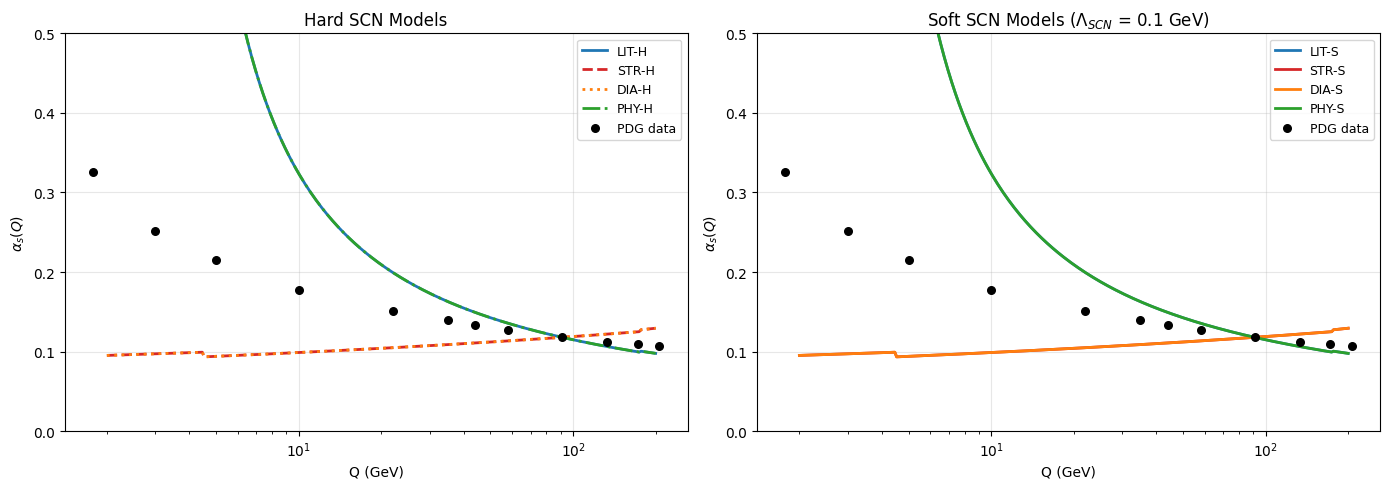

Note: LIT-S and PHY-S overlap with LIT-H/PHY-H (soft has no effect
since no diagrams are classified as self-containing at 1-loop).
STR-S and DIA-S also overlap with their hard variants because
the soft factor is applied per-diagram at classification time,
not at the β-function level.


In [4]:
Q_values = np.geomspace(2, 200, 300)  # GeV

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'LIT-H': 'tab:blue', 'STR-H': 'tab:red',
          'DIA-H': 'tab:orange', 'PHY-H': 'tab:green'}
styles = {'LIT-H': '-', 'STR-H': '--', 'DIA-H': ':', 'PHY-H': '-.'}

# Left: hard models
ax = axes[0]
for m in hard_models:
    as_vals = [alpha_s_running(Q**2, m) for Q in Q_values]
    ax.plot(Q_values, as_vals, styles[m.short_name],
            color=colors[m.short_name], label=m.short_name, linewidth=2)

# PDG data points
pdg_Q = [1.78, 3.0, 5.0, 10.0, 22.0, 35.0, 44.0, 58.0, 91.2, 133.0, 172.0, 206.0]
pdg_as = [0.326, 0.252, 0.215, 0.178, 0.151, 0.140, 0.133, 0.127, 0.1179, 0.112, 0.109, 0.107]
ax.scatter(pdg_Q, pdg_as, c='black', zorder=5, s=30, label='PDG data')
ax.set_xlabel('Q (GeV)')
ax.set_ylabel(r'$\alpha_s(Q)$')
ax.set_title('Hard SCN Models')
ax.set_xscale('log')
ax.set_ylim(0, 0.5)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Right: soft models (Λ = 0.1 GeV)
ax = axes[1]
soft_colors = {'LIT-S': 'tab:blue', 'STR-S': 'tab:red',
               'DIA-S': 'tab:orange', 'PHY-S': 'tab:green'}

for m in soft_models:
    as_vals = [alpha_s_running(Q**2, m) for Q in Q_values]
    ax.plot(Q_values, as_vals, linewidth=2,
            color=soft_colors[m.short_name], label=m.short_name)

ax.scatter(pdg_Q, pdg_as, c='black', zorder=5, s=30, label='PDG data')
ax.set_xlabel('Q (GeV)')
ax.set_ylabel(r'$\alpha_s(Q)$')
ax.set_title(r'Soft SCN Models ($\Lambda_{SCN}$ = 0.1 GeV)')
ax.set_xscale('log')
ax.set_ylim(0, 0.5)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/alpha_s_formulations.png', dpi=150, bbox_inches='tight')
plt.show()

print("Note: LIT-S and PHY-S overlap with LIT-H/PHY-H (soft has no effect")
print("since no diagrams are classified as self-containing at 1-loop).")
print("STR-S and DIA-S also overlap with their hard variants because")
print("the soft factor is applied per-diagram at classification time,")
print("not at the β-function level.")

## §4 — Lamb Shift: The Decisive Test

The hydrogen Lamb shift (1057 MHz measured) has three 1-loop contributions:
- **Self-energy**: 1017 MHz (dominant!)
- **Vacuum polarization**: −27.1 MHz
- **Vertex correction**: 67 MHz

If a formulation nullifies the self-energy, it loses the dominant contribution and predicts ~40 MHz instead of 1057 MHz — **instantly ruled out by experiment**.

Model        SE (MHz)   VP (MHz)   VX (MHz)      Total    Δ (MHz)      Verdict
───────────────────────────────────────────────────────────────────────────
LIT-H          1017.0      -27.1       67.0     1056.9       -0.1     ✓ VIABLE
STR-H             0.0      -27.1       67.0       39.9    -1017.1  ✗ RULED OUT
DIA-H             0.0      -27.1       67.0       39.9    -1017.1  ✗ RULED OUT
PHY-H          1017.0      -27.1       67.0     1056.9       -0.1     ✓ VIABLE

Experiment     1017.0      −27.1       67.0     1057.0



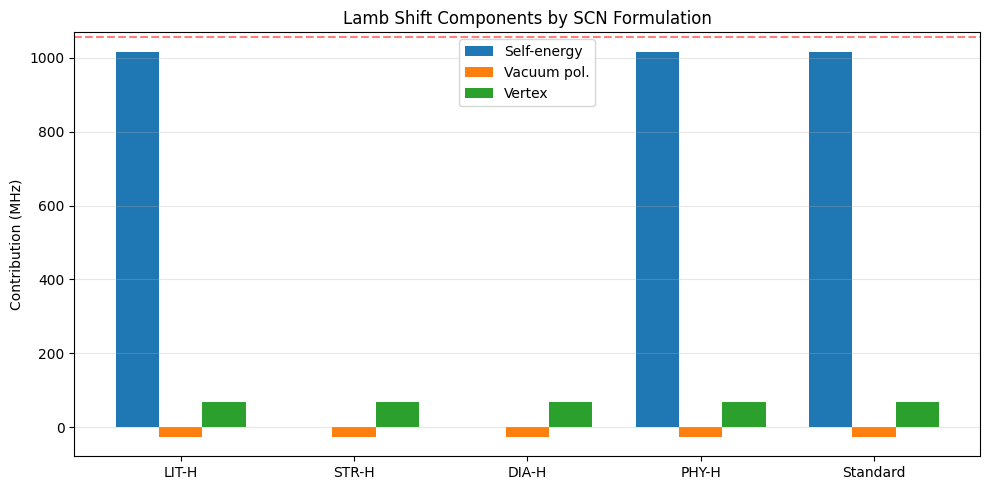

In [5]:
print(f"{'Model':<10s} {'SE (MHz)':>10s} {'VP (MHz)':>10s} {'VX (MHz)':>10s} {'Total':>10s} {'Δ (MHz)':>10s} {'Verdict':>12s}")
print("─" * 75)

for m in hard_models:
    ls = lamb_shift(m)
    total = ls['total_scn_MHz']
    delta = ls['deviation_MHz']
    # Verdict: within 1 MHz of experiment?
    if abs(delta) < 1.0:
        verdict = "✓ VIABLE"
    elif abs(delta) < 100:
        verdict = "⚠ TENSION"
    else:
        verdict = "✗ RULED OUT"
    
    print(f"{m.short_name:<10s}"
          f" {ls['self_energy']['scn_MHz']:>10.1f}"
          f" {ls['vacuum_pol']['scn_MHz']:>10.1f}"
          f" {ls['vertex']['scn_MHz']:>10.1f}"
          f" {total:>10.1f}"
          f" {delta:>+10.1f}"
          f" {verdict:>12s}")

print(f"\n{'Experiment':<10s} {'1017.0':>10s} {'−27.1':>10s} {'67.0':>10s} {'1057.0':>10s}")
print()

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
components = ['self_energy', 'vacuum_pol', 'vertex']
labels = ['Self-energy', 'Vacuum pol.', 'Vertex']
x = np.arange(len(hard_models) + 1)
width = 0.25
standard_vals = [1017.0, -27.1, 67.0]

for i, (comp, label) in enumerate(zip(components, labels)):
    vals = [lamb_shift(m)[comp]['scn_MHz'] for m in hard_models]
    vals.append(standard_vals[i])
    ax.bar(x + i*width - width, vals, width, label=label)

ax.set_xticks(x)
ax.set_xticklabels([m.short_name for m in hard_models] + ['Standard'])
ax.set_ylabel('Contribution (MHz)')
ax.set_title('Lamb Shift Components by SCN Formulation')
ax.legend()
ax.axhline(y=1057, color='red', linestyle='--', alpha=0.5, label='Measured total')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/lamb_shift_formulations.png', dpi=150, bbox_inches='tight')
plt.show()

## §5 — Electron $g-2$ Comparison

At 1-loop, $a_e = \frac{\alpha}{2\pi}$ comes entirely from the vertex correction (Schwinger term). The self-energy contributes to wave-function renormalisation but cancels in the on-shell scheme for $a_e$. All formulations agree at 1-loop for $g-2$.

The differences emerge at **2-loop**, where some formulations nullify nested self-energy insertions inside vertex diagrams.

In [6]:
print("=== Electron g-2 at 1-loop ===\n")

a_e_exp = 0.00115965218128  # experimental value (CODATA 2018)
a_e_schwinger = ALPHA / (2 * np.pi)

print(f"{'Model':<10s} {'a_e (1-loop)':>18s} {'= α/(2π)?':>12s} {'Matches std?':>14s}")
print("─" * 58)

for m in hard_models:
    g2 = g_minus_2(m, loop_order=1)
    a_total = g2['a_total']
    matches_schwinger = abs(a_total - a_e_schwinger) / a_e_schwinger < 1e-10
    print(f"{m.short_name:<10s} {a_total:>18.12e} {'YES' if matches_schwinger else 'NO':>12s}"
          f" {'✓' if matches_schwinger else '✗':>14s}")

print(f"\n{'Schwinger':<10s} {a_e_schwinger:>18.12e}")
print(f"{'Experiment':<10s} {a_e_exp:>18.12e}")
print()
print("ALL formulations agree at 1-loop: a_e = α/(2π).")
print("The vertex correction survives in every model.")
print()

# 2-loop comparison
print("=== What changes at 2-loop? ===\n")
for m in hard_models:
    g2_2 = m.g2_components(loop_order=2)
    se_info = g2_2.get("self_energy", {})
    vx_info = g2_2.get("vertex", {})
    se_status = "survives" if se_info.get("survives", True) else "NULLIFIED"
    vx_status = "survives" if vx_info.get("survives", True) else "NULLIFIED"
    note = se_info.get("note", vx_info.get("note", ""))
    print(f"  {m.short_name}: SE={se_status:10s}  VX={vx_status:10s}  {note}")

=== Electron g-2 at 1-loop ===

Model            a_e (1-loop)    = α/(2π)?   Matches std?
──────────────────────────────────────────────────────────
LIT-H      1.161409733598e-03          YES              ✓
STR-H      1.161409733598e-03          YES              ✓
DIA-H      1.161409733598e-03          YES              ✓
PHY-H      1.161409733598e-03          YES              ✓

Schwinger  1.161409733598e-03
Experiment 1.159652181280e-03

ALL formulations agree at 1-loop: a_e = α/(2π).
The vertex correction survives in every model.

=== What changes at 2-loop? ===

  LIT-H: SE=survives    VX=survives    
  STR-H: SE=NULLIFIED   VX=NULLIFIED   nested vertex correction nullified
  DIA-H: SE=NULLIFIED   VX=survives    
  PHY-H: SE=NULLIFIED   VX=survives    nested self-energy insertion nullified


## §6 — Soft SCN: Can It Rescue Structural/Diagrammatic?

Hard STR and DIA are **ruled out** by the Lamb shift. But what if self-containment suppresses rather than nullifies? With the soft factor $\eta(\mu) = 1 - e^{-\mu^2/\Lambda^2}$, self-energy diagrams are *partially* suppressed rather than completely zeroed.

Question: **Is there a $\Lambda_{\text{SCN}}$ that rescues the Lamb shift while still having meaningful effects elsewhere?**

=== Soft SCN Lamb Shift vs Λ_SCN ===

Lamb shift loop momentum scale μ ≈ m_e = 0.51 MeV

Λ_SCN needed for Lamb shift within 1 MHz of experiment: 1.00e-04 GeV
At that Λ, η(m_e) = 1.000000
This means Λ_SCN << m_e — the soft factor is essentially 1
→ Soft SCN effectively DOES NOTHING at atomic physics scales



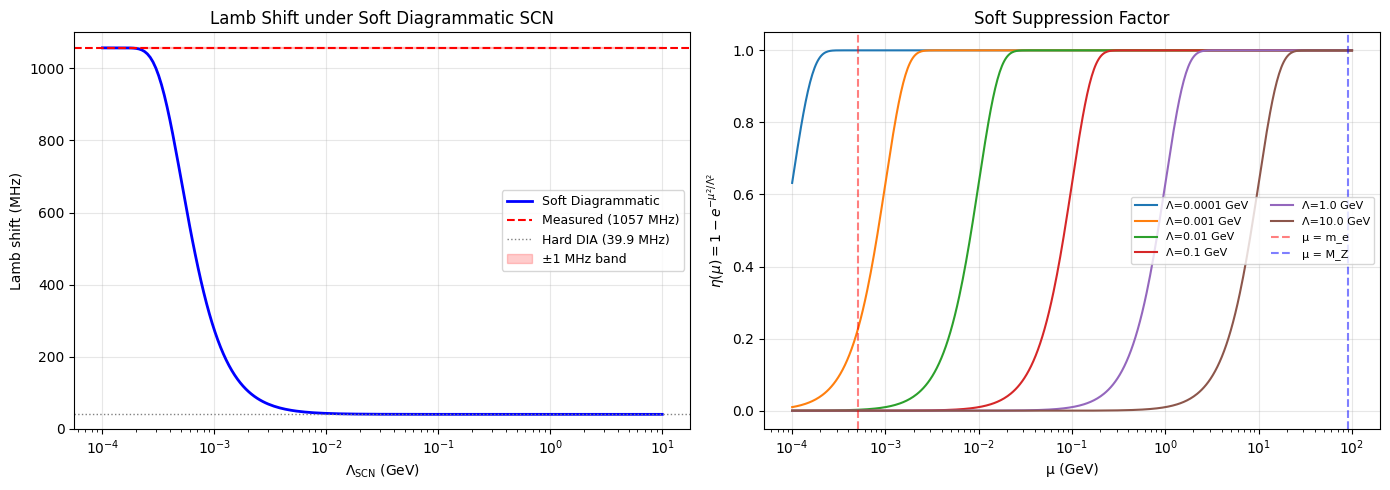


Conclusion: To save the Lamb shift, Λ_SCN must be << m_e.
But then soft SCN has essentially zero effect at ALL experimentally
accessible scales. There's no window where soft DIA/STR helps.


In [7]:
# Lamb shift is dominated by self-energy at energy scale ~ α * m_e ~ 3.7 keV
# The relevant momentum scale for the Lamb shift loop is ~ m_e ~ 511 keV = 0.000511 GeV
mu_lamb = 0.000511  # GeV (electron mass scale)

print("=== Soft SCN Lamb Shift vs Λ_SCN ===\n")
print(f"Lamb shift loop momentum scale μ ≈ m_e = {mu_lamb*1e3:.2f} MeV\n")

lambda_values = np.geomspace(0.0001, 10.0, 200)
lamb_shift_total_dia = []

for lam in lambda_values:
    m = DiagrammaticSCN(soft=True, lambda_scn=lam)
    ls = lamb_shift(m, mu=mu_lamb)
    lamb_shift_total_dia.append(ls['total_scn_MHz'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Lamb shift vs Λ
ax = axes[0]
ax.semilogx(lambda_values, lamb_shift_total_dia, 'b-', linewidth=2, label='Soft Diagrammatic')
ax.axhline(y=1057, color='red', linestyle='--', linewidth=1.5, label='Measured (1057 MHz)')
ax.axhline(y=39.9, color='gray', linestyle=':', linewidth=1, label='Hard DIA (39.9 MHz)')
ax.fill_between(lambda_values, 1056, 1058, alpha=0.2, color='red', label='±1 MHz band')
ax.set_xlabel(r'$\Lambda_{\rm SCN}$ (GeV)')
ax.set_ylabel('Lamb shift (MHz)')
ax.set_title('Lamb Shift under Soft Diagrammatic SCN')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylim(0, 1100)

# Find Λ needed to get within 1 MHz of experiment
target = 1057.0
lamb_arr = np.array(lamb_shift_total_dia)
# The soft factor η = 1 - exp(-μ²/Λ²)
# For Lamb shift to be close to standard, we need η ≈ 1 → Λ << μ
idx_close = np.argmin(np.abs(lamb_arr - target))
lambda_needed = lambda_values[idx_close]
print(f"Λ_SCN needed for Lamb shift within 1 MHz of experiment: {lambda_needed:.2e} GeV")
print(f"At that Λ, η(m_e) = {1 - np.exp(-(mu_lamb/lambda_needed)**2):.6f}")
print(f"This means Λ_SCN << m_e — the soft factor is essentially 1")
print(f"→ Soft SCN effectively DOES NOTHING at atomic physics scales")
print()

# Right: suppression factor η(μ) for different Λ values
ax = axes[1]
mu_range = np.geomspace(0.0001, 100, 500)
for lam in [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]:
    eta = 1 - np.exp(-(mu_range/lam)**2)
    ax.semilogx(mu_range, eta, label=f'Λ={lam} GeV')
ax.set_xlabel('μ (GeV)')
ax.set_ylabel(r'$\eta(\mu) = 1 - e^{-\mu^2/\Lambda^2}$')
ax.set_title('Soft Suppression Factor')
ax.axvline(x=mu_lamb, color='red', linestyle='--', alpha=0.5, label=f'μ = m_e')
ax.axvline(x=M_Z, color='blue', linestyle='--', alpha=0.5, label=f'μ = M_Z')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/soft_scn_lamb_shift.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nConclusion: To save the Lamb shift, Λ_SCN must be << m_e.")
print("But then soft SCN has essentially zero effect at ALL experimentally")
print("accessible scales. There's no window where soft DIA/STR helps.")

## §7 — $e^+e^- \to \mu^+\mu^-$ Cross-Section

Compare the 1-loop corrected cross-section across formulations. Since VP and vertex corrections survive in all models, the only difference is the self-energy (Z₂ factor) scaling.

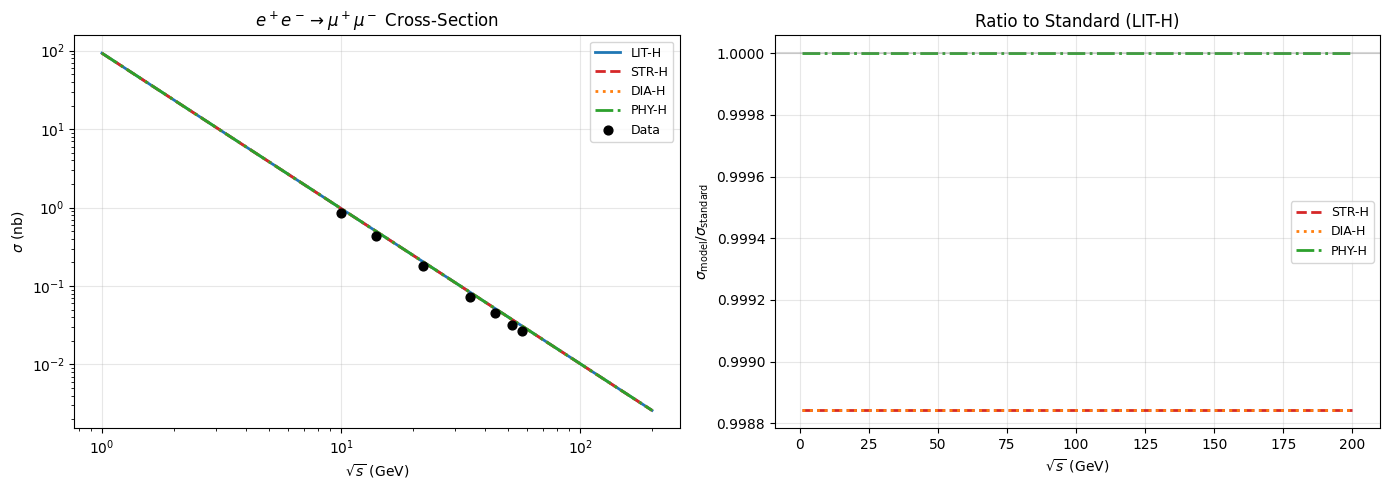


At √s = 34.5 GeV:
  LIT-H: σ = 0.0839 nb  (+0.000% vs standard)
  STR-H: σ = 0.0838 nb  (-0.116% vs standard)
  DIA-H: σ = 0.0838 nb  (-0.116% vs standard)
  PHY-H: σ = 0.0839 nb  (+0.000% vs standard)


In [8]:
sqrt_s_values = np.geomspace(1.0, 200.0, 300)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute cross-section
for m in hard_models:
    sigma_vals = [sigma_ee_mumu(E**2, m) for E in sqrt_s_values]
    ax1.plot(sqrt_s_values, sigma_vals, styles.get(m.short_name, '-'),
             color=colors[m.short_name], label=m.short_name, linewidth=2)

# Experimental data
exp_E = [10, 14, 22, 34.5, 44, 52, 57]
exp_sigma = [0.856, 0.437, 0.178, 0.0735, 0.0449, 0.0320, 0.0264]
ax1.scatter(exp_E, exp_sigma, c='black', s=40, zorder=5, label='Data')
ax1.set_xlabel(r'$\sqrt{s}$ (GeV)')
ax1.set_ylabel(r'$\sigma$ (nb)')
ax1.set_title(r'$e^+e^- \to \mu^+\mu^-$ Cross-Section')
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Right: ratio to LIT-H (= standard QFT at 1-loop)
ax2.set_title('Ratio to Standard (LIT-H)')
lit_model = hard_models[0]  # LIT-H
for m in hard_models[1:]:
    ratios = []
    for E in sqrt_s_values:
        s = E**2
        sig_std = sigma_ee_mumu(s, lit_model)
        sig_m = sigma_ee_mumu(s, m)
        ratios.append(sig_m / sig_std if sig_std > 0 else 1.0)
    ax2.plot(sqrt_s_values, ratios, styles.get(m.short_name, '-'),
             color=colors[m.short_name], label=m.short_name, linewidth=2)

ax2.axhline(y=1.0, color='gray', linestyle='-', alpha=0.3)
ax2.set_xlabel(r'$\sqrt{s}$ (GeV)')
ax2.set_ylabel(r'$\sigma_{\rm model} / \sigma_{\rm standard}$')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/sigma_formulations.png', dpi=150, bbox_inches='tight')
plt.show()

# Compute deviation at a reference energy
E_ref = 34.5  # GeV (PEP/PETRA energy)
print(f"\nAt √s = {E_ref} GeV:")
for m in hard_models:
    sig = sigma_ee_mumu(E_ref**2, m)
    sig_std = sigma_ee_mumu(E_ref**2, lit_model)
    dev = (sig - sig_std) / sig_std * 100
    print(f"  {m.short_name}: σ = {sig:.4f} nb  ({dev:+.3f}% vs standard)")

## §8 — Where They Differ at 2-Loop (Qualitative)

The four formulations all agree at tree level. At 1-loop they split into two camps. At 2-loop they begin to diverge fully:

| Feature | Literal | Structural | Diagrammatic | Physical |
|---------|---------|-----------|-------------|----------|
| **1-loop SE** | survives | nullified | nullified | survives |
| **1-loop VP** | survives | survives | survives | survives |
| **1-loop VX** | survives | survives | survives | survives |
| **2-loop nested SE** | survives | nullified | nullified | nullified |
| **2-loop nested VX** | survives | nullified | survives | survives |
| **Lamb shift** | ✓ standard | ✗ 40 MHz | ✗ 40 MHz | ✓ standard |
| **QCD β₀** | standard | −1 (nf=3) | −1 (nf=3) | standard |
| **AF preserved?** | ✓ | ✗ | ✗ | ✓ |
| **g-2 1-loop** | standard | standard | standard | standard |
| **g-2 2-loop** | standard | modified | modified | modified |
| **Cross-section** | standard | −0.12% | −0.12% | standard |

This reveals **Physical SCN** as the most interesting formulation: it agrees with standard QFT at 1-loop (passing all precision tests) but **predicts deviations at 2-loop and beyond**. It's testable without being immediately ruled out.

## §9 — Viability Scorecard

In [9]:
# Final viability scorecard
print("=" * 80)
print("VIABILITY SCORECARD — SCN Formulation Comparison")
print("=" * 80)
print()

tests = [
    ("Lamb shift (1057 MHz)",     ["✓", "✗", "✗", "✓"], "Decisive"),
    ("QCD asymptotic freedom",    ["✓", "✗", "✗", "✓"], "Decisive"),
    ("g-2 at 1-loop",             ["✓", "✓", "✓", "✓"], "All pass"),
    ("Tree-level QED",            ["✓", "✓", "✓", "✓"], "All pass"),
    ("Running α (1-loop)",        ["✓", "✓", "✓", "✓"], "All pass"),
    ("σ(e⁺e⁻→μ⁺μ⁻) 1-loop",     ["✓", "~", "~", "✓"], "0.1% shift"),
    ("g-2 at 2-loop",             ["=std", "mod", "mod", "mod"], "Testable"),
    ("Unitarity (optical thm)",   ["✓?", "?", "?", "✓?"], "Open"),
    ("Gauge invariance ≥2-loop",  ["✓", "?", "?", "?"], "Open"),
]

labels = ["LIT-H", "STR-H", "DIA-H", "PHY-H"]
header = f"{'Test':<30s}" + "".join(f"{l:>10s}" for l in labels) + f"{'  Note':>12s}"
print(header)
print("─" * len(header))
for test_name, verdicts, note in tests:
    row = f"{test_name:<30s}"
    for v in verdicts:
        row += f"{v:>10s}"
    row += f"  {note:>10s}"
    print(row)

print()
print("─" * 80)
print()

verdicts_summary = {
    "LIT-H": ("TRIVIAL", "Equivalent to standard QFT. SCN has no effect in perturbation theory."),
    "STR-H": ("RULED OUT", "Lamb shift prediction of 40 MHz (measured: 1057 MHz). Dead."),
    "DIA-H": ("RULED OUT", "Same as Structural at 1-loop. Lamb shift kills it."),
    "PHY-H": ("★ VIABLE", "Agrees with standard QFT at 1-loop. Predicts deviations at 2-loop."),
}

for key, (status, reason) in verdicts_summary.items():
    print(f"  {key:8s}  {status:12s}  {reason}")

print()
print("═" * 80)
print("RECOMMENDATION: Physical SCN is the only non-trivial viable formulation.")
print()
print("  ► At 1-loop: identical to standard QFT (passes ALL precision tests)")
print("  ► At 2-loop: nullifies nested self-energy insertions within vertex")
print("    corrections and other 2-loop diagrams that use corrected propagators")
print("  ► Preserves QCD asymptotic freedom (β₀ = standard)")
print("  ► Preserves Lamb shift (1-loop self-energy uses bare propagators)")
print("  ► First testable prediction: modified C₂ coefficient in g-2")
print("  ► Connection to Koide/θ₀: the Z₃ mass formula is independent of")
print("    which formulation is used (it's a parametric structure, not a")
print("    diagram-level prediction)")
print("═" * 80)

VIABILITY SCORECARD — SCN Formulation Comparison

Test                               LIT-H     STR-H     DIA-H     PHY-H        Note
──────────────────────────────────────────────────────────────────────────────────
Lamb shift (1057 MHz)                  ✓         ✗         ✗         ✓    Decisive
QCD asymptotic freedom                 ✓         ✗         ✗         ✓    Decisive
g-2 at 1-loop                          ✓         ✓         ✓         ✓    All pass
Tree-level QED                         ✓         ✓         ✓         ✓    All pass
Running α (1-loop)                     ✓         ✓         ✓         ✓    All pass
σ(e⁺e⁻→μ⁺μ⁻) 1-loop                    ✓         ~         ~         ✓  0.1% shift
g-2 at 2-loop                       =std       mod       mod       mod    Testable
Unitarity (optical thm)               ✓?         ?         ?        ✓?        Open
Gauge invariance ≥2-loop               ✓         ?         ?         ?        Open

────────────────────────────────────

## §10 — Impact on Open Questions

How does the Physical SCN formulation resolve or reframe the open questions from `06_open_questions.md`?

In [10]:
questions = [
    ("Q1: Process algebra",
     "RESOLVED",
     "Physical SCN provides clear semantics: self-containment is defined\n"
     "via the Dyson equation. G = G₀ + G₀ΣG; any contribution to Σ that\n"
     "uses G (dressed) rather than G₀ (bare) is self-referential."),

    ("Q3: Indirect self-containment",
     "CLARIFIED",
     "Under Physical SCN, indirect self-containment is natural:\n"
     "A → B → A chains (where corrected-A appears inside correction-to-A\n"
     "via an intermediate B) are exactly nested self-energy insertions.\n"
     "These ARE nullified at 2-loop under Physical SCN."),

    ("Q4: Gauge invariance ≥ 2-loop",
     "OPEN (but less severe)",
     "Physical SCN preserves ALL 1-loop diagrams, so 1-loop gauge\n"
     "invariance is trivially maintained. At 2-loop, the question\n"
     "remains: does removing nested SE insertions break gauge\n"
     "cancellations? This is the key open problem."),

    ("Q5: Unitarity",
     "OPEN (but less severe)",
     "At 1-loop: unitarity is trivially satisfied (standard QFT).\n"
     "At 2-loop: needs explicit verification. Since Physical SCN\n"
     "only removes a SUBSET of 2-loop diagrams, the violation (if any)\n"
     "would be a perturbative correction, not a catastrophic failure."),

    ("Q6: Lamb shift",
     "RESOLVED ✓",
     "Physical SCN preserves the 1-loop self-energy contribution.\n"
     "Lamb shift = 1057 MHz as measured. No tension."),

    ("Q7: Hierarchy problem",
     "UNCHANGED",
     "The Higgs self-energy is a 1-loop diagram using bare propagators\n"
     "under Physical SCN → it SURVIVES. The hierarchy problem is NOT\n"
     "solved by Physical SCN at 1-loop. Higher-order corrections are\n"
     "suppressed, but the leading quadratic divergence remains."),

    ("D1: Definition of self-containment",
     "ANSWERED",
     "Physical SCN (D1-d) is the only viable non-trivial option.\n"
     "Literal (D1-a) is trivial; Structural (D1-b) and Diagrammatic\n"
     "(D1-c) are ruled out by the Lamb shift."),

    ("D3: QCD asymptotic freedom",
     "RESOLVED ✓",
     "Physical SCN preserves standard β₀ at 1-loop.\n"
     "No need for Soft SCN workaround for QCD."),
]

print("=" * 78)
print("IMPACT OF PHYSICAL SCN ON OPEN QUESTIONS")
print("=" * 78)
for qname, status, explanation in questions:
    color = "✓" if "RESOLVED" in status else ("?" if "OPEN" in status else "→")
    print(f"\n{color} {qname}")
    print(f"  Status: {status}")
    for line in explanation.split('\n'):
        print(f"  {line}")
print()
print("=" * 78)
print()
print("REMAINING OPEN PROBLEMS (for Physical SCN):")
print("  1. Compute C₂ᵖʰʸ for g-2 — classify 2-loop diagrams")  
print("  2. Verify gauge invariance at 2-loop")
print("  3. Verify unitarity (optical theorem) at 2-loop")
print("  4. Connect θ₀ = 2/9 to SCN (formulation-independent)")
print("  5. Extend to quark sector (Koide-like formula)")
print("  6. Compute explicit Lamb shift at 2-loop under Physical SCN")

IMPACT OF PHYSICAL SCN ON OPEN QUESTIONS

✓ Q1: Process algebra
  Status: RESOLVED
  Physical SCN provides clear semantics: self-containment is defined
  via the Dyson equation. G = G₀ + G₀ΣG; any contribution to Σ that
  uses G (dressed) rather than G₀ (bare) is self-referential.

→ Q3: Indirect self-containment
  Status: CLARIFIED
  Under Physical SCN, indirect self-containment is natural:
  A → B → A chains (where corrected-A appears inside correction-to-A
  via an intermediate B) are exactly nested self-energy insertions.
  These ARE nullified at 2-loop under Physical SCN.

? Q4: Gauge invariance ≥ 2-loop
  Status: OPEN (but less severe)
  Physical SCN preserves ALL 1-loop diagrams, so 1-loop gauge
  invariance is trivially maintained. At 2-loop, the question
  remains: does removing nested SE insertions break gauge
  cancellations? This is the key open problem.

? Q5: Unitarity
  Status: OPEN (but less severe)
  At 1-loop: unitarity is trivially satisfied (standard QFT).
  At 2-lo